# Preprocessing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/mekel16/Machine-Learning-Multilayer-Perceptron-/main/bbc-text.csv')
df

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...
...,...,...
2220,business,cars pull down us retail figures us retail sal...
2221,politics,kilroy unveils immigration policy ex-chatshow ...
2222,entertainment,rem announce new glasgow concert us band rem h...
2223,politics,how political squabbles snowball it s become c...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [ ]:
df.isna().sum()

category    0
text        0
dtype: int64

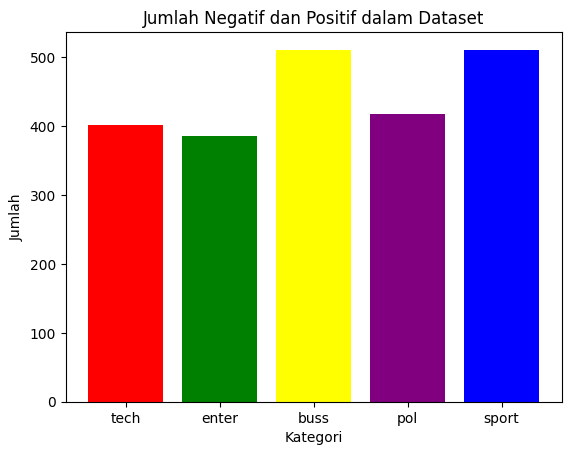

In [ ]:
import matplotlib.pyplot as plt

tech = (df['category'] == 'tech').sum()
ent = (df['category'] == 'entertainment').sum()
bus = (df['category'] == 'business').sum()
pol = (df['category'] == 'politics').sum()
sport = (df['category'] == 'sport').sum()
plt.bar(['tech','enter','buss','pol','sport'], [tech,ent,bus,pol,sport], color=['red', 'green','yellow','purple','blue'])
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.title('Jumlah Negatif dan Positif dalam Dataset')

plt.show()


In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')


# kolom_teks = 'text'
tokenized_texts = []
for teks in df['text']:
    tokens = word_tokenize(teks)
    tokenized_texts.append(tokens)

df['tokenized_text'] = tokenized_texts
df


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,category,text,tokenized_text
0,tech,tv future in the hands of viewers with home th...,"[tv, future, in, the, hands, of, viewers, with..."
1,business,worldcom boss left books alone former worldc...,"[worldcom, boss, left, books, alone, former, w..."
2,sport,tigers wary of farrell gamble leicester say ...,"[tigers, wary, of, farrell, gamble, leicester,..."
3,sport,yeading face newcastle in fa cup premiership s...,"[yeading, face, newcastle, in, fa, cup, premie..."
4,entertainment,ocean s twelve raids box office ocean s twelve...,"[ocean, s, twelve, raids, box, office, ocean, ..."
...,...,...,...
2220,business,cars pull down us retail figures us retail sal...,"[cars, pull, down, us, retail, figures, us, re..."
2221,politics,kilroy unveils immigration policy ex-chatshow ...,"[kilroy, unveils, immigration, policy, ex-chat..."
2222,entertainment,rem announce new glasgow concert us band rem h...,"[rem, announce, new, glasgow, concert, us, ban..."
2223,politics,how political squabbles snowball it s become c...,"[how, political, squabbles, snowball, it, s, b..."


In [ ]:
import re

def normalize_text(tokens):
    # Join tokens back into a single string
    text = ' '.join(tokens)

    # Pengecilan huruf
    text = text.lower()

    # Penghapusan simbol aneh (hanya menyisakan huruf, angka, dan spasi)
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Penghapusan spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenisasi ulang setelah normalisasi
    normalized_tokens = text.split()

    return normalized_tokens

df['normalized_text'] = df['tokenized_text'].apply(normalize_text)
df


,category,text,tokenized_text,normalized_text
0,tech,tv future in the hands of viewers with home th...,"[tv, future, in, the, hands, of, viewers, with...","[tv, future, in, the, hands, of, viewers, with..."
1,business,worldcom boss left books alone former worldc...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, boss, left, books, alone, former, w..."
2,sport,tigers wary of farrell gamble leicester say ...,"[tigers, wary, of, farrell, gamble, leicester,...","[tigers, wary, of, farrell, gamble, leicester,..."
3,sport,yeading face newcastle in fa cup premiership s...,"[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, in, fa, cup, premie..."
4,entertainment,ocean s twelve raids box office ocean s twelve...,"[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, s, twelve, raids, box, office, ocean, ..."
...,...,...,...,...
2220,business,cars pull down us retail figures us retail sal...,"[cars, pull, down, us, retail, figures, us, re...","[cars, pull, down, us, retail, figures, us, re..."
2221,politics,kilroy unveils immigration policy ex-chatshow ...,"[kilroy, unveils, immigration, policy, ex-chat...","[kilroy, unveils, immigration, policy, exchats..."
2222,entertainment,rem announce new glasgow concert us band rem h...,"[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, us, ban..."
2223,politics,how political squabbles snowball it s become c...,"[how, political, squabbles, snowball, it, s, b...","[how, political, squabbles, snowball, it, s, b..."


In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# kolom_teks = 'teks_bersih'
stop_words = set(stopwords.words('english'))
def hapus_stop_words(tokens):
    # kata_kunci = teks.split()  # Memecah teks menjadi kata-kata
    kata_tanpa_stopwords = [kata for kata in tokens if kata.lower() not in stop_words]  # Menghapus stop words
    # teks_baru = ' '.join(kata_tanpa_stopwords)  # Menggabungkan kembali kata-kata menjadi teks
    return kata_tanpa_stopwords

df['no_stopwords'] = df['normalized_text'].apply(hapus_stop_words)
# df.to_csv('data_tanpa_stopwords.csv', index=False)
df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,category,text,tokenized_text,normalized_text,no_stopwords
0,tech,tv future in the hands of viewers with home th...,"[tv, future, in, the, hands, of, viewers, with...","[tv, future, in, the, hands, of, viewers, with...","[tv, future, hands, viewers, home, theatre, sy..."
1,business,worldcom boss left books alone former worldc...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, boss, left, books, alone, former, w...","[worldcom, boss, left, books, alone, former, w..."
2,sport,tigers wary of farrell gamble leicester say ...,"[tigers, wary, of, farrell, gamble, leicester,...","[tigers, wary, of, farrell, gamble, leicester,...","[tigers, wary, farrell, gamble, leicester, say..."
3,sport,yeading face newcastle in fa cup premiership s...,"[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, fa, cup, premiershi..."
4,entertainment,ocean s twelve raids box office ocean s twelve...,"[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, twelve, raids, box, office, ocean, twe..."
...,...,...,...,...,...
2220,business,cars pull down us retail figures us retail sal...,"[cars, pull, down, us, retail, figures, us, re...","[cars, pull, down, us, retail, figures, us, re...","[cars, pull, us, retail, figures, us, retail, ..."
2221,politics,kilroy unveils immigration policy ex-chatshow ...,"[kilroy, unveils, immigration, policy, ex-chat...","[kilroy, unveils, immigration, policy, exchats...","[kilroy, unveils, immigration, policy, exchats..."
2222,entertainment,rem announce new glasgow concert us band rem h...,"[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, us, ban..."
2223,politics,how political squabbles snowball it s become c...,"[how, political, squabbles, snowball, it, s, b...","[how, political, squabbles, snowball, it, s, b...","[political, squabbles, snowball, become, commo..."


In [ ]:
# import pandas as pd
# import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
nltk.download('punkt')
nltk.download('wordnet')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Fungsi untuk melakukan stemming pada teks
def stemming(teks):
    # kata_kunci = word_tokenize(teks)  # Tokenisasi kata
    kata_stem = [stemmer.stem(kata) for kata in teks]  # Melakukan stemming pada setiap kata
    teks_stem = ' '.join(kata_stem)  # Menggabungkan kembali kata-kata menjadi teks
    return teks_stem


# stemming pada teks dalam kolom
df['stemmed'] = df['normalized_text'].apply(stemming)


df


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,category,text,tokenized_text,normalized_text,no_stopwords,stemmed
0,tech,tv future in the hands of viewers with home th...,"[tv, future, in, the, hands, of, viewers, with...","[tv, future, in, the, hands, of, viewers, with...","[tv, future, hands, viewers, home, theatre, sy...",tv futur in the hand of viewer with home theat...
1,business,worldcom boss left books alone former worldc...,"[worldcom, boss, left, books, alone, former, w...","[worldcom, boss, left, books, alone, former, w...","[worldcom, boss, left, books, alone, former, w...",worldcom boss left book alon former worldcom b...
2,sport,tigers wary of farrell gamble leicester say ...,"[tigers, wary, of, farrell, gamble, leicester,...","[tigers, wary, of, farrell, gamble, leicester,...","[tigers, wary, farrell, gamble, leicester, say...",tiger wari of farrel gambl leicest say they wi...
3,sport,yeading face newcastle in fa cup premiership s...,"[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, in, fa, cup, premie...","[yeading, face, newcastle, fa, cup, premiershi...",yead face newcastl in fa cup premiership side ...
4,entertainment,ocean s twelve raids box office ocean s twelve...,"[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, s, twelve, raids, box, office, ocean, ...","[ocean, twelve, raids, box, office, ocean, twe...",ocean s twelv raid box offic ocean s twelv the...
...,...,...,...,...,...,...
2220,business,cars pull down us retail figures us retail sal...,"[cars, pull, down, us, retail, figures, us, re...","[cars, pull, down, us, retail, figures, us, re...","[cars, pull, us, retail, figures, us, retail, ...",car pull down us retail figur us retail sale f...
2221,politics,kilroy unveils immigration policy ex-chatshow ...,"[kilroy, unveils, immigration, policy, ex-chat...","[kilroy, unveils, immigration, policy, exchats...","[kilroy, unveils, immigration, policy, exchats...",kilroy unveil immigr polici exchatshow host ro...
2222,entertainment,rem announce new glasgow concert us band rem h...,"[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, us, ban...","[rem, announce, new, glasgow, concert, us, ban...",rem announc new glasgow concert us band rem ha...
2223,politics,how political squabbles snowball it s become c...,"[how, political, squabbles, snowball, it, s, b...","[how, political, squabbles, snowball, it, s, b...","[political, squabbles, snowball, become, commo...",how polit squabbl snowbal it s becom commonpla...


## SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['stemmed'], df['category'],
                                                    test_size = 0.20,
                                                    random_state = 42)

# Ekstraksi Fitur

---



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
tfidf_vectorizer = TfidfVectorizer()
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)
print(tfidf_train.shape)
print(tfidf_test.shape)


(1780, 21310)
(445, 21310)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Inisialisasi TF-IDF Vectorizer dengan max_features
tfidf_vectorizer_lemmatized = TfidfVectorizer()

# Ekstraksi fitur dari teks yang telah di-lemmatisasi
tfidf_features_lemmatized = tfidf_vectorizer_lemmatized.fit_transform(X_train)

# Ubah hasil ekstraksi fitur menjadi DataFrame
df_tfidf_features_lemmatized = pd.DataFrame(tfidf_features_lemmatized.toarray(), columns=tfidf_vectorizer_lemmatized.get_feature_names_out())

# Menampilkan hasil ekstraksi fitur menggunakan TF-IDF untuk setiap baris
for index, row in df_tfidf_features_lemmatized.iterrows():
    print(f"Category: {df['category'][index]}, Text: {df['text'][index]}")
    print("TF-IDF Lemmatized:")
    print(row)
    print("\n")

Streaming output truncated to the last 5000 lines.
zubair         0.0
zurich         0.0
zuton          0.0
zvonareva      0.0
zvyagintsev    0.0
Name: 1467, Length: 21310, dtype: float64


Category: politics, Text: election  could be terror target  terrorists might try to target the uk in the run-up to the election  london s most senior police officer has said.  sir ian blair said terror groups would remember the effect of the madrid bomb on spain s general election last year. other potential targets were the royal wedding and the uk s presidency of the european union and g8  he said. he refused to say if there was specific information about the risk of a pre-poll attack. no 10 was similarly cautious but said the threat was real.  the comments come after tony blair defended his controversial anti-terror proposals  warning that it would be wrong to wait for an attack before acting. sir ian told a meeting of the metropolitan police authority it would be  unwise  to speculate about wheth

In [ ]:
# Menampilkan fitur yang dipertahankan
features = tfidf_vectorizer_lemmatized.get_feature_names_out()
print("Features:", features)

Features: ['00' '000' '0001' ... 'zuton' 'zvonareva' 'zvyagintsev']


In [ ]:
# Menampilkan distribusi nilai TF-IDF untuk beberapa fitur
print(df_tfidf_features_lemmatized.describe())

                00          000         0001       000300        00051  \
count  1780.000000  1780.000000  1780.000000  1780.000000  1780.000000   
mean      0.000184     0.008709     0.000028     0.000028     0.000026   
std       0.003629     0.022079     0.001179     0.001161     0.001115   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       0.000000     0.000000     0.000000     0.000000     0.000000   
max       0.100992     0.341291     0.049743     0.049001     0.047044   

            000acr        000bn         000m      000seat    000strong  ...  \
count  1780.000000  1780.000000  1780.000000  1780.000000  1780.000000  ...   
mean      0.000047     0.000058     0.001133     0.000018     0.000177  ...   
std       0.001981     0.002451     0.012939     0.000759     0.003809  ...   
min       0.00000

In [ ]:
# import pandas as pd

# DataFrame yang berisi hasil ekstraksi fitur TF-IDF
# df_tfidf_features_stemmed = pd.DataFrame(tfidf_features_stemmed.toarray())
df_tfidf_features_lemmatized = pd.DataFrame(tfidf_features_lemmatized.toarray())

# Fungsi untuk menghitung Gini Index
def gini_index(series):
    sorted_series = series.sort_values()
    n = len(sorted_series)
    coef_1 = 2 / n
    weighted_sum = (sorted_series * (n - sorted_series.index + 1)).sum()
    coef_2 = 1 / n
    total = sorted_series.sum()
    return coef_1 * weighted_sum / total - coef_2

# Menghitung Gini Index untuk setiap kolom dalam DataFrame
# gini_stemmed = df_tfidf_features_stemmed.apply(gini_index)
gini_lemmatized = df_tfidf_features_lemmatized.apply(gini_index)

# # Menampilkan Gini Index
# print("Gini Index for TF-IDF Stemmed Features:")
# print(gini_stemmed)
# print("\n")

print("Gini Index for TF-IDF Lemmatized Features:")
print(gini_lemmatized)

Gini Index for TF-IDF Lemmatized Features:
0        0.548013
1        0.989941
2        1.839888
3        1.106180
4        1.920787
           ...   
21305    0.401685
21306    1.063151
21307    0.585955
21308    1.608427
21309    1.155378
Length: 21310, dtype: float64


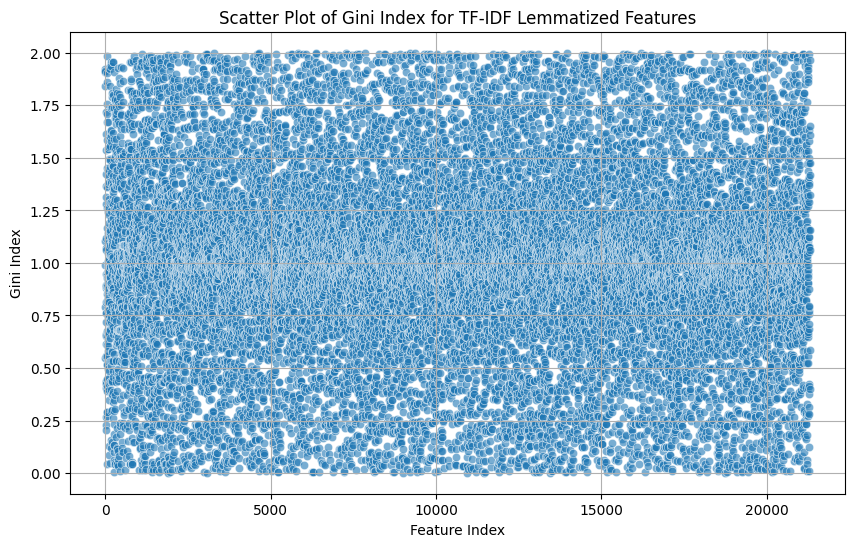

In [ ]:
# Menampilkan scatter plot Gini Index
plt.figure(figsize=(10, 6))
plt.scatter(range(len(gini_lemmatized)), gini_lemmatized, alpha=0.6, edgecolors='w', linewidth=0.5)
plt.title('Scatter Plot of Gini Index for TF-IDF Lemmatized Features')
plt.xlabel('Feature Index')
plt.ylabel('Gini Index')
plt.grid(True)
plt.show()

Cara Membaca Scatter Plot:
Sumbu X (Feature Index): Ini adalah indeks fitur dari hasil TF-IDF. Setiap titik di sepanjang sumbu X mewakili fitur unik yang dihasilkan dari vektor TF-IDF.
Sumbu Y (Gini Index): Ini adalah nilai Gini Index untuk setiap fitur. Gini Index mengukur ketidakmerataan atau disparitas distribusi nilai TF-IDF untuk suatu fitur di seluruh dokumen.
Distribusi Titik: Setiap titik pada plot mewakili nilai Gini Index dari satu fitur tertentu.
Interpretasi:
Range Gini Index: Nilai Gini Index berkisar antara 0 dan 2. Nilai yang lebih tinggi menunjukkan distribusi nilai TF-IDF yang lebih tidak merata di antara dokumen.
Pola Distribusi: Dari plot, kita dapat melihat bahwa sebagian besar fitur memiliki Gini Index yang beragam dan tersebar di seluruh rentang nilai. Ini menunjukkan bahwa beberapa fitur memiliki distribusi TF-IDF yang sangat tidak merata (dengan nilai Gini yang tinggi), sementara yang lain lebih merata (dengan nilai Gini yang rendah).
Titik Padat: Kerapatan titik-titik di plot menunjukkan berapa banyak fitur yang memiliki nilai Gini tertentu. Semakin banyak titik pada level tertentu, semakin banyak fitur yang memiliki distribusi TF-IDF yang serupa.
Beberapa Observasi:
Gini Index Rendah: Fitur dengan Gini Index rendah (dekat 0) adalah fitur yang distribusi nilai TF-IDF-nya cukup merata di seluruh dokumen.
Gini Index Tinggi: Fitur dengan Gini Index tinggi (mendekati 2) adalah fitur yang nilai TF-IDF-nya sangat tidak merata di antara dokumen.
Penyebaran Vertikal: Plot menunjukkan penyebaran vertikal yang cukup seragam, yang mengindikasikan bahwa tidak ada dominasi fitur di satu sisi nilai Gini Index.


# **Multilayer Perceptron**

In [ ]:
from sklearn.neural_network import MLPClassifier

clf_ = MLPClassifier(hidden_layer_sizes=(6,5),
                    random_state=5,
                    verbose=True,
                    learning_rate_init=0.01)

clf_.fit(tfidf_train,y_train)

Iteration 1, loss = 1.69241145
Iteration 2, loss = 1.24495475
Iteration 3, loss = 0.76680014
Iteration 4, loss = 0.51979018
Iteration 5, loss = 0.39492436
Iteration 6, loss = 0.25895612
Iteration 7, loss = 0.15783645
Iteration 8, loss = 0.11438652
Iteration 9, loss = 0.08817255
Iteration 10, loss = 0.06359259
Iteration 11, loss = 0.04040922
Iteration 12, loss = 0.02548493
Iteration 13, loss = 0.01502433
Iteration 14, loss = 0.00923324
Iteration 15, loss = 0.00629286
Iteration 16, loss = 0.00478832
Iteration 17, loss = 0.00403599
Iteration 18, loss = 0.00357925
Iteration 19, loss = 0.00329328
Iteration 20, loss = 0.00309345
Iteration 21, loss = 0.00293997
Iteration 22, loss = 0.00281672
Iteration 23, loss = 0.00271414
Iteration 24, loss = 0.00262692
Iteration 25, loss = 0.00254974
Iteration 26, loss = 0.00248022
Iteration 27, loss = 0.00241908
Iteration 28, loss = 0.00236223
Iteration 29, loss = 0.00231007
Iteration 30, loss = 0.00226234
Iteration 31, loss = 0.00221769
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(6, 5), learning_rate_init=0.02,
              random_state=5, verbose=True)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.metrics import accuracy_score


ypred=clf_.predict(tfidf_test)
confus_mat1 = confusion_matrix(y_test, ypred)
print(accuracy_score(y_test,ypred))
print(classification_report(y_test,ypred))


0.950561797752809
               precision    recall  f1-score   support

     business       0.99      0.90      0.94       101
entertainment       0.87      1.00      0.93        81
     politics       0.91      0.99      0.95        83
        sport       0.99      0.95      0.97        98
         tech       1.00      0.93      0.96        82

     accuracy                           0.95       445
    macro avg       0.95      0.95      0.95       445
 weighted avg       0.96      0.95      0.95       445



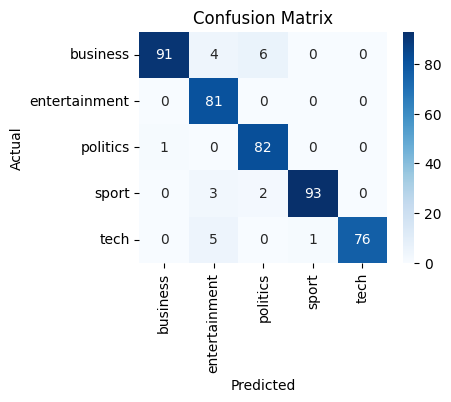

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
sns.heatmap(confus_mat1, annot=True, fmt='d', cmap='Blues', xticklabels=clf_.classes_, yticklabels=clf_.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Compare dengan KNN

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

In [ ]:
# Mencari nilai k terbaik
k_range = range(1, 6)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, tfidf_train, y_train, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())

# Plot hasil
# plt.plot(k_range, k_scores, marker='o')
# plt.xlabel('Number of Neighbors K')
# plt.ylabel('Cross-Validated Accuracy')
# plt.title('KNN Accuracy for Different Values of K')
# plt.show()

# Menemukan nilai k dengan akurasi tertinggi
optimal_k = k_range[k_scores.index(max(k_scores))]
print(f'Nilai k optimal: {optimal_k}')

Nilai k optimal: 4


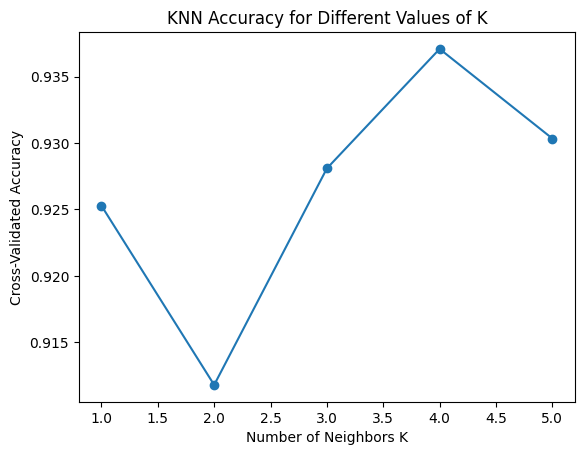

In [ ]:
# Plot hasil
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy for Different Values of K')
plt.show()

In [ ]:
compare_knn = KNeighborsClassifier(n_neighbors=4,  # Menentukan jumlah tetangga terdekat
                               algorithm='auto',  # Algoritma yang digunakan untuk menghitung tetangga terdekat
                               weights='uniform')  # Bobot yang sama untuk semua tetangga

# Melatih model
compare_knn.fit(tfidf_train,y_train)


KNeighborsClassifier(n_neighbors=4)

In [ ]:
pred=compare_knn.predict(tfidf_test)
confusmat_knn = confusion_matrix(y_test, pred)
print('akurasi',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

akurasi 0.9483146067415731
               precision    recall  f1-score   support

     business       0.94      0.89      0.91       101
entertainment       0.96      0.96      0.96        81
     politics       0.90      0.95      0.92        83
        sport       0.99      0.99      0.99        98
         tech       0.95      0.95      0.95        82

     accuracy                           0.95       445
    macro avg       0.95      0.95      0.95       445
 weighted avg       0.95      0.95      0.95       445



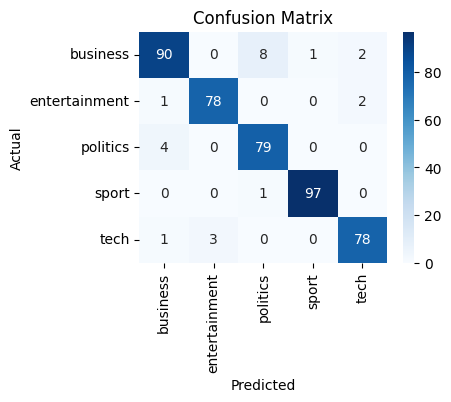

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
sns.heatmap(confusmat_knn, annot=True, fmt='d', cmap='Blues', xticklabels=compare_knn.classes_, yticklabels=compare_knn.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Testing MLP

In [ ]:
new_text_data = [
    "In an exhilarating race at the London Marathon, Kenyan athlete Eliud Kipchoge shattered the previous world record, completing the 26.2-mile course in an astonishing 2 hours and 1 minute. Kipchoge’s remarkable feat has left the running community in awe, and his achievement is being celebrated worldwide",
    "Hollywood’s latest sci-fi epic, “Galactic Odyssey,” had its grand premiere last night. A-list celebrities, including lead actors Emma Stone and Michael B. Jordan, graced the red carpet. The film, directed by visionary filmmaker Ava DuVernay, promises mind-bending visuals and an interstellar adventure that has fans buzzing with excitement",
    "At the United Nations Climate Change Conference, leaders from 195 countries reached a historic agreement. The pact includes aggressive targets to limit global warming, reduce carbon emissions, and transition to renewable energy sources. Critics argue that implementation remains a challenge, but the commitment signals a united effort to combat climate change on a global scale",
    "Ashton Agar has become the latest Australian player to make the bold decision to become a freelance global gun-for-hire, and he couldn't be more excited about it. But the 30-year-old says he remains committed to trying to play for Australia in all three formats, including Test cricket, and playing domestic cricket for Western Australia when he's available despite opting not to sign a state contract for 2024-25."
]


new_tfidf = tfidf_vectorizer_lemmatized.transform(new_text_data)
# prediksi data teks menggunakan model yang telah di buat '(clf)'
new_predictions = clf_.predict(new_tfidf)

for text, prediction in zip(new_text_data, new_predictions):
    print(f"Text: {text}\nPredicted Label: {prediction}\n")

Text: In an exhilarating race at the London Marathon, Kenyan athlete Eliud Kipchoge shattered the previous world record, completing the 26.2-mile course in an astonishing 2 hours and 1 minute. Kipchoge’s remarkable feat has left the running community in awe, and his achievement is being celebrated worldwide
Predicted Label: sport

Text: Hollywood’s latest sci-fi epic, “Galactic Odyssey,” had its grand premiere last night. A-list celebrities, including lead actors Emma Stone and Michael B. Jordan, graced the red carpet. The film, directed by visionary filmmaker Ava DuVernay, promises mind-bending visuals and an interstellar adventure that has fans buzzing with excitement
Predicted Label: entertainment

Text: At the United Nations Climate Change Conference, leaders from 195 countries reached a historic agreement. The pact includes aggressive targets to limit global warming, reduce carbon emissions, and transition to renewable energy sources. Critics argue that implementation remains a ch

Testing KNN

In [ ]:
new_text_data = [
    "In an exhilarating race at the London Marathon, Kenyan athlete Eliud Kipchoge shattered the previous world record, completing the 26.2-mile course in an astonishing 2 hours and 1 minute. Kipchoge’s remarkable feat has left the running community in awe, and his achievement is being celebrated worldwide",
    "Hollywood’s latest sci-fi epic, “Galactic Odyssey,” had its grand premiere last night. A-list celebrities, including lead actors Emma Stone and Michael B. Jordan, graced the red carpet. The film, directed by visionary filmmaker Ava DuVernay, promises mind-bending visuals and an interstellar adventure that has fans buzzing with excitement",
    "At the United Nations Climate Change Conference, leaders from 195 countries reached a historic agreement. The pact includes aggressive targets to limit global warming, reduce carbon emissions, and transition to renewable energy sources. Critics argue that implementation remains a challenge, but the commitment signals a united effort to combat climate change on a global scale",
    "Ashton Agar has become the latest Australian player to make the bold decision to become a freelance global gun-for-hire, and he couldn't be more excited about it. But the 30-year-old says he remains committed to trying to play for Australia in all three formats, including Test cricket, and playing domestic cricket for Western Australia when he's available despite opting not to sign a state contract for 2024-25."
]


new_tfidf = tfidf_vectorizer_lemmatized.transform(new_text_data)
# prediksi data teks menggunakan model yang telah di buat '(clf)'
new_predictions = compare_knn.predict(new_tfidf)

for text, prediction in zip(new_text_data, new_predictions):
    print(f"Text: {text}\nPredicted Label: {prediction}\n")

Text: In an exhilarating race at the London Marathon, Kenyan athlete Eliud Kipchoge shattered the previous world record, completing the 26.2-mile course in an astonishing 2 hours and 1 minute. Kipchoge’s remarkable feat has left the running community in awe, and his achievement is being celebrated worldwide
Predicted Label: sport

Text: Hollywood’s latest sci-fi epic, “Galactic Odyssey,” had its grand premiere last night. A-list celebrities, including lead actors Emma Stone and Michael B. Jordan, graced the red carpet. The film, directed by visionary filmmaker Ava DuVernay, promises mind-bending visuals and an interstellar adventure that has fans buzzing with excitement
Predicted Label: entertainment

Text: At the United Nations Climate Change Conference, leaders from 195 countries reached a historic agreement. The pact includes aggressive targets to limit global warming, reduce carbon emissions, and transition to renewable energy sources. Critics argue that implementation remains a ch